<a href="https://colab.research.google.com/github/hamzayawa/pytorch-learning/blob/main/01_maternal_health_risk/Maternal_Health_Lab_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# My first PyTorch model
### Maternal Health Risk Classification · Google Colab
**One notebook. Nine stages. Your own prediction app.**

Click **Connect**, then run each cell from the top using its ▶ button or **Shift + Enter**. A CPU runtime is enough.

The dataset is included inside this notebook. All model code is here too.

A teaching demo using sample data, not a medical tool.

## Before we start
Run these two setup cells once per new session. The first installs our tools; the second unpacks the included data.

After a runtime reset, run from the top again to restore the data and train a fresh model.

In [ ]:
%pip install -q "torch>=2.2,<3" "pandas>=2,<4" "matplotlib>=3.7,<4" "gradio==6.29.0"

In [ ]:
# @title Unpack the included dataset — click Run { display-mode: "form" }
# @markdown This restores the prepared data bundled inside this notebook. No upload needed.
from pathlib import Path
import base64
import hashlib
import zlib

# This text is compressed data, not a trained model or a Python helper.
bundled_data = """
eNrlXA1wXNV1XkmxbGSBYsA/GFvIdmwW/8hayZb/ZO9q466xn2WLNTKyQVHX0kNavJb0pJUth5o4OJi6dSeTNEMS/kLSSaCmkCap
g9vaWsEM2EkMraHtkE4KLbRD2kJoaAgMw0x7v7v7rY/uvv2RZEJmsjtH995zzz3nO+eeu++9e3fVbJV8wuOZMsWT8ZrpmerZF4nb
/T2RWHu/Hek8uLwzEo9U9+2NhYKTPbuTr8PFhxyPt7VcDYj3R6I97dGevsH4gFPUEe/t7+iubh+MR2MDZUrBnsForLM9bvcM9Pa3
768tc4q93tbJatyAkox02U5JckhZKNYbie9IMsucT7QWKZkaZ1JriSo7+gad0qY7psSdyTdZnqauIqv0qDPFKlK1o85lxzo6emMx
uyMe7e0ZKNve32n3250box3xMqfshrAzNe6Uh53LW6cCrD0QJ9YruhWU7pLupCmfU9Fd2lRdHHc+qUxYbbAwzSqy2o46Vx7rhp6r
4s7VYWe6cDoW2WPHBpwZSUUpP7b29nSl3Zipddc6s5TurqK4c00S/j3ObEv9uTapeE7cmRt2Ki8CTOm9LgUwqaTOqeoutdrizjyN
7x5nPlQsSKr4VNxZGHYWaRV6dHtPZJ894Fzf5qhwY5pjvQeq+qMDe50bdHNftDPZXNx6mWp2R7u6k+0lduvlinG7HYkP9tspNUvb
nGVePRONasaqW8tUbcdBNYOxaEew2Vmu7W6MRtKcmtZixQnucHzaWrC38+DN9r4+p1Zbu9GO9MfDKsmcOlvnQl+/vT9qH3BWHHJW
XrRT3+as8lrXWAusuValtcA2za5uc9Z4rbut49ZuRUN2Boq1bc46r9WsukNWi9VgE1RDm7PeuylQncz4TYHFrFSxMoeVWbfrlz3a
jQ1tjl8paD2ckkpXdnlMTqpiG44H2pxGr7VTAWtWtDXZHVYTsNXeb8ecYJvzaa8xMxu79Xv0bP6ePajnS+eNPRTZ1xdT8xU65Gzy
dqv43ehV0SuzplszFJWrKFaodoNVZc206q2l1jzrSusqFeFKy6/+1lurVKRrrWmqfrn6W6ta09Tbq6UaFG+mKsutRlUPKj2N1jLV
g/4FqlahehqUnWsVLdAWKlRfhXpfpbV80vJpFLXKCrTPsdZpDupXa1vXq1qVxoh3ud2tJnizV81cyBqyOhW1K9qqartVuVtN/JA1
oOvHxXtI8ZP9+IuyR/8dSv9Nli0pqU7dfzzVczzFRbtD2dqtKDkiiWLIspT+Tq19IK1td8pqT9oO9Hba3SoBt3hVVGrVLDcqalDk
U4oalUCDKnfrWFoQTg5RLobU3wbdgxGWmhlLS1spHS0pPcnx+Gvpse2K157iN+ikb1C2QBjj1ygArFbJNup3UippaavOw5C23Jwa
WWt3q5ViqURfxLS+9ut43b8pUJleKefxel5VkislvWREpTJjWaUr11BhuuJlV02GcNr6xUqdfom1nK5UZnDqWJmfYSKtcDbduY6c
tBfVGS5XZXyAuCBMR4yj0tbTnByjCqnUFmD9OgYqs5KO4cVoZHSlK4sLkEmHLkelMmOaCqnUjGvUmCrpWU7nfBrz/IyETHNm5a3Y
3eqisVWtpV2Hs1wiXK8nYxH+LansCmSvjGS9YGYKj8nWRDGPZFV4qUxMMJgFBTzvbUiBekbGZX0ku4wna2JnJkB+qHa3un1qSt4+
bVXUpC96+NukOZ9OXcyCusQFLah6cDHFZa5Z9Yf0O3nRC+pLa/KiCR61btX9QfUO6RueJv1OjmvSFNJ2d2rbYX2JDmrt5CQt7dQ2
d6bsAUdI3bThXnWgIxKz+9v32ZEeZ9uoh4iNvYN7Ynb6MWK7fgJY4TSrJ4DSuHMTngBK73HCeALYkXwCuDnutISdnfrpJKVXF84t
qaeIpI6VTmtSx66Ujt3QcWtSx21xpy3sfGawutmaPGX/vy9/9FV1awlqzvq4WOmZbj4uVt/e269Y7fvt/gH1RBYKTuNT48WXDxae
evtnR4AJlN3CPE9NhoXUs2N7JBbt6tln98RDwaWZRnK86lcAgP+A8594JCjOCWCWZ7UJYM/BuN2L58xQcMWY7PIVi8bjMRsY7ln/
+jWlykppTgzTPavcnsqX14SCdeMBEO16ePj2b76x4Zn3v/a3Hwx8eT3qS6NvDoOOrLc3nNvxB37Ud9VvTED25ydrEvWPn/JfMedY
4tEl5/3gYdwb4RY/2gdWzk38+Ie3JB5/6q4ExvTufcZ/5Z9++wzGQc/kk5clIPPWP80IPP3mh/4/ueMBP2yCj37oM23DFviQgU7w
0Ac+6anbvpOADyPrZmpf1q7am4BN6Kl4vmcYPNqHXdgEDuDEWGBEmzzKAufnHnxQtyEDH6ELOOgDsCEmkPnCIyMaN+xCdlK42r//
xcZ0nCAPWcQFMYMcsKAOeygRP/DhAyj0sy+P8vMrF2ZrGWBFP2NGP6CDuKAbfJTAi37G58++8fUN9AmyGIOx4NE++CjhL22C5/2X
v07HTdqSMYQ/nH/ImjlAefQBg1s+wDb6YB/xw/yCZ+YHcMs8kT5zvl/973/0L/pqVQAysCtzYc5/3evn2EM7SwJogw88k7+2Seug
XsbK9Bl90h7kGTtgpz8mdsTFxI06SoyFPsRg60+qhqkfctCF9qdumpzGgjig/tlVywPmmoZPaMMm+iQOrmvGGHPNNU8ssAUckGcO
mZ8RmHfwMd7MH9iFDvRxTqmL65kxAQ5+hsC+mUOIN3xlzM28IUEe+rZ0PzucSxd03PJSt44x1jDzX84DMKF8bvG3/XLdSB+IHzpQ
Qh9kMEfMU+YL1zTWklzfKNE/69lj/hkvvOh/7TP3J1DWDRXpNvioo0Qf6jte+MIZlCTIyTHUAzr7+PwE5dgmr+bXJSMo2TZlpQ3Z
lnKgW7Z7tJ5/63o98dxf7U1QFpj3vD6cIF7UwSNf6gZhrLQlsUr+hdORDdRvYqP/0M866Kubn8yILcuyvtqAjKGpj22U8BGYiJUY
pY/sA9kH7k7HS9o/d9fzCRkHE6/EJ/GYcyjtAYO0ZcZQ5oSMK2wgF9AHTLnyQWIx55D5ZOYJSjme48wcM/XJPrPfzWfmdC7fs9li
Dpu4zVgx5xAz8s2cAp91uW7Zpg5py5RzW+fEYurLFre+1TNGTB5z2G0eiGFTyTuJXPPolkO5Ph/cKJcuENarXFPmXDLezAMZb7c5
lWtKxkWSnG9JRyc/tOGtNUf9j778yvALdy7zr3zyPs1DG3zUyXMGD/obv3XkDOoc977vP7QMy/bObQnIYzxkIYM2SuhHGfjOuwnK
vnPyZNo2caA0bVOecmjHF/5fgjK0KUuQxEO+1M1+8FCn77SDEnz6IfvJZywog1iA4Bttm3Fi7FhSFnopVxOJJ2RMJVZiYIxln4w1
/YQ+zi/jgLEcY+JDKWMF/TIu0p60JWMo4+YmCxvIBeJzywepT8619A15IPNS6iEG4jV1yfyU9mTuyRx08wNEP8xYsU67p+8ozord
xG2uBdbJl3PF+WLd9JN12mKb/ea6lrLEwtgQgzkPHMP1beaPzGH5GUNd5jzyM4RjZOzRzzXDuswb6pD65v/h/IZsumQsZNzMuWSM
aZfrir6AvzA6Pe2HXOeIC3CiBMFfkFsd5dlJ1waK4z/1f3/fv545suWXw/0fWAmn7+1h0INvFCV6D/x+AHX0kf/mqYN+lBgr5cKx
qxPvf/8rw6BZjedH0QvPvpIm2MhH1AOCbUmws6euRhN0g4cSfIxFeeKqz28A//mGlgRo9o52jRPU4H3cz3ou+u7mtdpHlG703g1T
EyTIoURsEIuNgenDx2/arEtgQQlCH2QgH37oQABt+AgeSvAlBvhCn0mQZR2+yFiBTB7sYn6hGyViBEyReXP9KMHnPAEPeJCDHeiC
fdThHzCZGAsh5pck2MG8QPefL6kNoJ6PgP3M4JpELplCMcEPnbepeSAf62EsPmbLj4mQzC0Q4oMS82H2yRwEdtYxv6gjZijhozlG
8jjHJOZsoYQ5lW0zLwsh5Emhslwzl5rgh1xLsMM1gT7wEFvUuaZAkOF6RfuJJ+fqeeAawucQSuTM5F8u0uuXn0+IN0p8pgWr79bz
P//Vt4ZBHzxy2M96LnKTu/WJVwoa+5ukV26rDAArsE0UH8cXogd2s8Um33iOZQl51HONGysmyksbufoKwVDofIyn74qOpsBY5C81
wT7sgdyw5MNljhkvdmKQ80TdbvM7kVzHuikEZ745zZY/hWB0k3GzN5F45rPrhuGff1Q93BH+ow3sW3TomdPZbEBOlm79Jsn+t186
6bd++ovhpYfrdVn95v4NKFev+5UuJe/Rl5/S5apJ/6BlP1f/jh/j0I+6lAX/rK8vgTFnXuv3YwzaqKN/9rYP16NNQv/pv3gxQRym
bcigDzLsIx7wUScWYKdfaKNOf6R/4KN9r+/eBPtAxA6sxISSOjEWbdgkfvoPGdQpgzbGyzjBV5QYz7jQBog+mPFEnWPIJ17U6Qfa
lKEvIOKR8UEpY4e6jBH5JhZpT9qSMeQcIY6cY8aVsZM+u+XDXZ5wwsxPYmebeWDmCecIMm75Zs6rzHv6SpLxMeMLHu1JO5ABfpnT
2bCbuOk/CJggW/93dQnaJ9E/5qmcZxkzuZ5lPKWvZl6ZuGScZQ5J+Se+9+GIuZZk3kCH+ZlD/6R+mbtomznEOLjFXH5GyLzIpQs6
QDJurMtc4uee9N3MG+kHPyP5uQeS+ihr1tGPb4j88Y/eOP/YPI8HlOsbItNdvyHic/3+Dc42cf7I83CeY/OcmOe+OA/F2eaxpf/r
bznxJT++OyDPiCEfPLBQn61DBmfUOBPFGSnPgfE9Cp7n8/wYxO888DsV/L4F2sCCs2zw75u5IgA8aOO8l2fMGM+zep6hQh7+4PyV
Z7j0ATIYxzNX2CEWnDnjOwuMBb+XQOw4973w62kBypCPs2T6he978GyccZTnuzi74HkDzy94ZoHzCfNsjOcXOOOU5xxuZJ4bmWdc
qPMMxeS7ne0Cq9QlzzVpL9u5KPurN/n0uYt5/sLzJsaCZ3U8byR2nu2aZ8PSV2Ay/ZHnN9hflOcncu8V+4bmvjv3Jbl3iX1J7hFz
b5LnDzynkOchtIFxOI+QZzpyfxgl91LlvrncF5VnQrTJvVspz/EcB79Y0g6wMBbcF0ed5wgkqUv6hL1g7jG77WXTJnRijwH7Atw7
lfukcg+U+57YU8CeEPcTQNz3AXEvEXtb2JeALPcTsTcDvdz3w14F9o3knhb20bg/l2vvS+6bmXthct+KxP2pbHtM2fZkoKfQ/Rv4
hXhy75V7jdxrIV3KZ5Zcz0okPhPm2vvI9/wFHWPZ8yjk+Y3Pgdn2mYjdbZx8huZ4ub9j6pLPF/KaLeu8nkPGvA/kfZW8R5D3NbgX
4T0QiPfB5v0RdUGebfkcJe+X5b2d+WzAccQg70fkfY28v6G/1M97fXlPRuymjPRJPiNJrPK5DjzcD9215KWnT6k7IFCu+6FJrvdD
taFgkWd3cUoqW+kx2kVGacoVZWkXZdFXnEVfked3+1X0O1oW/5aWRWNcB54s+V4of6xyY8Vf/BHHfbx+TvQ13ngWjxNn8cckd6ni
NNb5K/6I7I7XXvHHFM+iAq93xQXy863HfNfNfGWh+PP5Wyh/ovY8E7Q31nGFxqnoEufPRz1+vNdhzxjzsHiC93vjzZPiAtfZpc5v
3H/fubY5tHqqxwMa+/133aj774/7PvJS3R+NV+9v6rpYaB5ni+N4+z/q+S20P991aLzXmXz2sV4e+ZuFU36uFILGvn+/wnX/fu3B
tfP/smJ94Ltn7m88fe7WQMsXvxdx3gsH7nzom8GqB6oCN2x57PyBx1oDZ5ev+8nCQ+EAcLzXc/MJ/AOFmjy/NL3cFcfKUPCyizh+
fOTp7eWNiwMNr7183wNHfYGbb+05ce5XiwM//PsLS3dVlga++D+zJp147l3/tqXhh1e+W6XtHz41tCy//RmectN++ofEU9IA6sqg
8cLDXS35f7+70LMk4wfE2qUBuz8aiUU/G8E/jmqPdoaC1xf6W1qfeq1es2qNz1ezcmVdTW29r0a9V9fXrfCtrvPV19f71qyoq63R
P3P+wXM/+AX+qYlXoyzSqUWc8kfWMzOQZ/k/XKYS+TvqylEKll/hyfPrbFOX/En0vFG6vuSiK+N32KY6+evmWaPUXVnhyfqralOL
PAGbPkrLfRUe999FmyrkptFoFad87ip8pgp53Rut4txadxW1pgr5UTBaxY0hdxV1pgq5ikerGNrsrmKFqUIuxNEqPFvcVaw0VciV
N2OUhsOZKrKkmlwXC0fpeDFTh/uKbbZKS5fyPxGULEsrKDfK7SWpEFn8WC7Fvx3znN128eO62ZpUmhxTruWTsv8Pl9hnng==
"""
prepared_data = zlib.decompress(base64.b64decode(bundled_data))
assert hashlib.sha256(prepared_data).hexdigest() == "30b624e66dca5be670b7da8bb6846bb71bc7f1f0aaa4ba381b79c0ebaca3b828", "The bundled dataset has changed. Please use a fresh copy of this notebook."
Path("data").mkdir(exist_ok=True)
Path("data/maternal_ready.pt").write_bytes(prepared_data)
print("Data ready! Let's build our model.")


Data ready! Let's build our model.


## 1. Our tools
PyTorch builds and trains the network. Matplotlib draws our learning plot.

In [ ]:
import torch
from torch import nn
import pandas as pd
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.set_num_threads(2)

## 2. Load the data
The setup cell restored `data/maternal_ready.pt`. It contains separate training and test sets, already scaled for the model. The preview shows the original readings.

**X** contains the six readings; **y** contains the answer: low, mid or high risk.

**BP** means blood pressure; **BS** means blood sugar. Which column is the answer?

In [ ]:
data = torch.load("data/maternal_ready.pt", weights_only=True)
X_train, y_train = data["train_inputs"], data["train_labels"]
X_test, y_test = data["test_inputs"], data["test_labels"]
label_names = data["label_names"]

print(f"Training examples: {len(X_train)} | Test examples: {len(X_test)}")
pd.DataFrame(data["preview"])

Training examples: 359 | Test examples: 93


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


## 3. Build the neural network
**6 input numbers**, **16 units** in the middle, **3 output scores**.

ReLU helps the model learn more flexible patterns.

In [ ]:
model = nn.Sequential(
    nn.Linear(6, 50),
    nn.Linear(50, 3)
)
model

Sequential(
  (0): Linear(in_features=6, out_features=50, bias=True)
  (1): Linear(in_features=50, out_features=3, bias=True)
)

## 4. Set the learning rules
**Loss** measures how wrong the model is. The **optimizer** adjusts it. We will do 250 practice rounds.

In [ ]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
epochs = 250

In [ ]:
6*50*3

900

## 5. Train the model
Predict, measure the error, work out an adjustment, then update. Repeat!

`zero_grad()` clears the previous round's adjustment; `backward()` works out the next one.

In [ ]:
losses = []
model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    scores = model(X_train)
    loss = loss_function(scores, y_train) #grade
    loss.backward()
    optimizer.step() # parent
    losses.append(loss.item())

print("Training finished!")

Training finished!


## 6. Watch it learn
**Guess first:** did the training error go up or down?

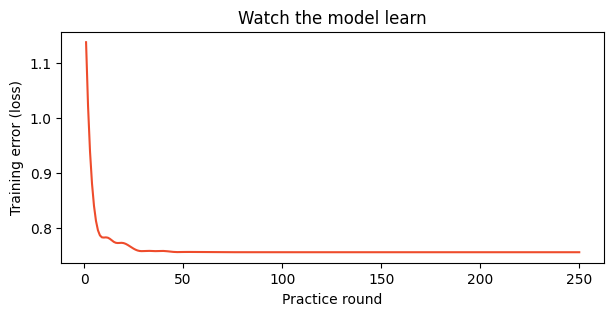

In [ ]:
plt.figure(figsize=(7, 3))
plt.plot(range(1, epochs + 1), losses, color="#EE4C2C")
plt.xlabel("Practice round")
plt.ylabel("Training error (loss)")
plt.title("Watch the model learn")
plt.show()

## 7. Give it an unseen quiz
Test examples were kept out of training. How many answers does our model get right?

In [ ]:
model.eval()
with torch.inference_mode():
    predictions = model(X_test).argmax(dim=1)

correct = (predictions == y_test).sum().item()
print(f"Quiz score: {correct} out of {len(y_test)} correct ({correct / len(y_test):.0%}).")

Quiz score: 63 out of 93 correct (68%).


## 8. Make one prediction
Predict a single test example. `argmax()` chooses the answer with the highest score.

Try changing `example = 0` to `example = 1`.

In [ ]:
example = 0
display(pd.DataFrame(data["test_examples"]).iloc[[example]])
with torch.inference_mode():
    scores = model(X_test[example:example + 1])
prediction = scores.argmax().item()

print("Model prediction:", label_names[prediction])
print("Recorded answer: ", label_names[y_test[example].item()])

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
0,35,85,60,11.0,102.0,86


Model prediction: high risk
Recorded answer:  high risk


## 9. Try the app
Gradio turns our prediction function into a form. Enter sample readings, then click **Predict**.

The function scales the inputs using the saved training values and asks the model we just trained. Keep temperature in **°F** and blood sugar in **mmol/L**.

Colab opens the app below and creates a temporary public link. Use the sample readings; keep this runtime connected while trying the app. If the form does not appear, open the link printed below.

In [ ]:
import gradio as gr
import math

# The colours match our workshop slides.
navy, cream, coral, mint = "#17324D", "#FAF2E3", "#EC6554", "#A4D8C6"
theme = gr.themes.Soft(primary_hue="orange", secondary_hue="teal", neutral_hue="slate", font=["Arial", "sans-serif"]).set(
    body_background_fill=cream, body_background_fill_dark=cream,
    body_text_color=navy, body_text_color_dark=navy,
    block_background_fill="#FFFFFF", block_background_fill_dark="#FFFFFF",
    input_background_fill="#FFFFFF", input_background_fill_dark="#FFFFFF",
    block_label_text_color=navy, block_label_text_color_dark=navy,
    button_primary_background_fill=navy, button_primary_background_fill_dark=navy,
    button_primary_text_color="#FFFFFF", button_primary_text_color_dark="#FFFFFF",
)
css = """
.gradio-container {max-width:1100px !important; margin:auto; padding:24px !important;}
#predict-button {border-radius:14px; min-height:54px; font-size:18px; background:#EC6554 !important; color:#17324D !important;}
#predict-button:hover {background:#17324D !important; color:#FAF2E3 !important;}
#readings label span {color:#17324D !important; background:#FAF2E3 !important;}
#readings {border:2px solid #17324D; border-radius:20px; padding:22px;}
"""

def result_card(title, detail):
    return f"""<div style="background:{mint};color:{navy};border:2px solid {navy};
        border-radius:20px;padding:28px;min-height:230px;font-family:Arial,sans-serif;">
        <div style="font-size:13px;font-weight:bold;letter-spacing:2px;">MODEL OUTPUT</div>
        <h2 style="font-size:36px;line-height:1.2;margin:24px 0 16px;color:{navy};">{title}</h2>
        <p style="font-size:17px;line-height:1.6;">{detail}</p>
        </div>"""

ready = result_card("What will it predict?", "Choose a sample or enter six readings, then press Predict category.")

def predict_risk(age, systolic, diastolic, sugar, temperature, heart_rate):
    values = [age, systolic, diastolic, sugar, temperature, heart_rate]
    if any(v is None or not math.isfinite(v) or v <= 0 for v in values):
        raise gr.Error("Please enter a positive number in all six fields.")
    readings = torch.tensor([values], dtype=torch.float32)
    inputs = ((readings - data["scaler_mean"]) / data["scaler_scale"]).float()
    model.eval()
    with torch.inference_mode():
        answer = model(inputs).argmax(dim=1).item()
    return result_card(label_names[answer].title(),
        "Predicted category from the training dataset. This is not a diagnosis or a probability of complications.")

with gr.Blocks(title="Maternal Health Risk Lab", analytics_enabled=False) as demo:
    gr.HTML(f"""<div style="background:{navy};color:{cream};padding:30px;border-radius:20px;margin-bottom:20px;font-family:Arial,sans-serif;">
        <div style="color:{mint};font-size:13px;font-weight:bold;letter-spacing:2px;">MATERNAL HEALTH RISK LAB</div>
        <h1 style="font-family:Georgia,serif;font-size:38px;line-height:1.2;margin:14px 0;color:{cream};">Meet the model you trained.</h1>
        <p style="font-size:18px;margin:0;line-height:1.5;color:{cream};">Six readings. Three possible categories. Try it for yourself.</p>
        </div>""")
    with gr.Row(equal_height=False):
        with gr.Column(scale=3, min_width=300, elem_id="readings"):
            gr.Markdown("### ① Enter sample readings")
            with gr.Row():
                age = gr.Number(label="Age (years)", value=35)
                heart_rate = gr.Number(label="Heart rate (bpm)", value=86)
            with gr.Row():
                systolic = gr.Number(label="Systolic BP (mmHg)", value=85)
                diastolic = gr.Number(label="Diastolic BP (mmHg)", value=60)
            with gr.Row():
                sugar = gr.Number(label="Blood sugar (mmol/L)", value=11)
                temperature = gr.Number(label="Temperature (°F)", value=102)
            predict = gr.Button("Predict category →", variant="primary", elem_id="predict-button")
        with gr.Column(scale=2, min_width=280):
            gr.Markdown("### ② Explore the prediction")
            result = gr.HTML(ready)
            gr.Markdown("**Try this:** change one reading, predict again, and compare. The category may stay the same.")
    fields = [age, systolic, diastolic, sugar, temperature, heart_rate]
    gr.Examples(examples=pd.DataFrame(data["test_examples"]).iloc[:3].values.tolist(),
                inputs=fields, label="Start with a sample from the dataset")
    gr.Markdown("**Learning demo only.** These are general dataset labels, not predictions of a specific complication. Use sample readings, not personal health information.")
    predict.click(predict_risk, inputs=fields, outputs=result, api_name="predict_risk")
    for field in fields:
        field.change(lambda: ready, outputs=result, queue=False)

demo.launch(inline=True, share=True, height=1000, theme=theme, css=css)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://472e8cb0e1ef64ebde.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Your turn:** explain the difference between training and testing to a teammate.

<details>
<summary>Where did our data come from?</summary>

Ahmed, M. (2020), [UCI Maternal Health Risk](https://doi.org/10.24432/C5DP5D), licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). Downloaded 30 September 2026 from the [UCI repository](https://archive.ics.uci.edu/dataset/863/maternal+health+risk). The original data comes from Bangladesh.

**Prepared for this workshop:** 562 exact duplicate rows were removed from the downloaded 1,014 rows, leaving 452 examples. Identical sets of input readings were kept together when splitting into 359 training and 93 test examples (GroupShuffleSplit, seed 42, 20% of groups held out). Scaling was fitted on the training data only. Labels are encoded as 0 = low risk, 1 = mid risk, 2 = high risk. Original readings are kept for previews and the app examples.

There are 416 distinct input profiles; 35 have conflicting labels. These and unusual readings remain in the data. No identical input profile crosses the split, but there are no patient identifiers to verify a split by patient. The model predicts dataset labels and has not been validated for clinical use or for Sokoto.

| Reading | Unit |
|---|---|
| Age | Years |
| SystolicBP / DiastolicBP | mmHg |
| BS (blood sugar) | mmol/L |
| BodyTemp | °F |
| HeartRate | Beats per minute |

The setup cell contains a compressed copy of the prepared dataset, not a trained model. You build and train the model yourself in stages 3–5. No separate data file, helper script or Google Drive connection is required.

</details>

<details>
<summary>Colab tips</summary>

- Upload this `.ipynb` through **File → Upload notebook** in [Google Colab](https://colab.research.google.com/).
- For a fresh run, restart the session and run every cell in order, including setup.
- If Colab asks you to restart after installing libraries, do so, then run from the top.
- The final app uses Gradio's `share=True` setting for a temporary public demo link. It only works while the runtime and app are running.
- This version uses Colab's regular cell controls. The local Jupyter cell-by-cell extension is for the laptop version.

References: [Colab FAQ](https://research.google.com/colaboratory/faq.html) · [Gradio sharing guide](https://gradio.app/guides/sharing-your-app).

</details>